## Download dataset dari Kaggle
*Mengimpor library kagglehub*

Apa yang dilakukan:
- Mengimpor library kagglehub
- Mengunduh dataset shrutimechlearn/churn-modelling dari Kaggle
- Menyimpan path file dataset ke variabel path

Kegunaan:
- Menyiapkan file dataset untuk analisis selanjutnya
- Memastikan data tersedia lokal sebelum dibaca

In [2]:
import kagglehub

path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")

print("Path to dataset files:", path)

c:\Users\Kimi Thora\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Kimi Thora\.cache\kagglehub\datasets\shrutimechlearn\churn-modelling\versions\1


## Membaca data dan mengecek info dasar

Apa yang dilakukan:
- Mengimpor pandas dan numpy
- Membaca file CSV Churn_Modelling.csv ke DataFrame df
- Menampilkan ringkasan struktur data dengan df.info()

Kegunaan:
- Memuat dataset ke dalam memori
- Mengetahui jumlah baris/kolom, tipe data, dan nilai non-null

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(path + "/Churn_Modelling.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


## Import library visualisasi dan konfigurasi 

Apa yang dilakukan: 
- Mengimpor library visualisasi matplotlib dan seaborn
- Mengimpor LabelEncoder dari sklearn.preprocessing
- Mengatur gaya plot seaborn menjadi whitegrid
- Mengatur ukuran default figure menjadi 10x6

Kegunaan:
- Menyiapkan lingkungan visualisasi data
- Mengatur tampilan plot agar konsisten dan lebih jelas

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

## Menampilkan header data

Apa yang dilakukan:
- Menampilkan 5 baris pertama dataset

Kegunaan:
- Memeriksa secara cepat bentuk data dan nilai awal
- Melihat nama kolom dan tipe nilai yang umum


In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Definisi kelas DatasetDescription

Apa yang dilakukan:
- Membuat kelas untuk mendeskripsikan dataset
- Menyediakan metode untuk:
- melihat ukuran dataset
- menampilkan nama kolom
- preview beberapa baris pertama

Kegunaan:
- Mengorganisir pemeriksaan awal dataset menjadi fungsi yang terstruktur
- Membuat ulang penggunaan lebih mudah jika ingin menjalankan lagi

In [6]:
class DatasetDescription:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def dataset_shape(self):
        print("=" * 10)
        print("SHAPE DATASET")
        print("=" * 10)
        
        print(f"Jumlah Baris : {self.df.shape[0]}")
        print(f"Jumlah Kolom : {self.df.shape[1]}")
        
    def dataset_columns(self):
        print("=" * 10)
        print("NAMA KOLOM")
        print("=" * 10)
        
        print(self.df.columns.tolist())
        
    def dataset_preview(self, n=5):
        print("=" * 10)
        print("PREVIEW DATASET")
        print("=" * 10)
        
        display(self.df.head(n))

## Menggunakan DatasetDescription

Apa yang dilakukan:
- Membuat objek desc dari DatasetDescription
- Menjalankan:
- dataset_shape
- dataset_columns
- dataset_preview

Kegunaan:
- Menampilkan ringkasan awal dataset secara rapi
- Memverifikasi struktur dan konten data dengan cepat

In [10]:
desc = DatasetDescription(df)

desc.dataset_shape()
desc.dataset_columns()
desc.dataset_preview()

SHAPE DATASET
Jumlah Baris : 10000
Jumlah Kolom : 14
NAMA KOLOM
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
PREVIEW DATASET


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Definisi kelas DataQualityCheck

Apa yang dilakukan:
- Membuat kelas untuk pemeriksaan kualitas data
- Menyediakan metode untuk:
- mengecek missing values
- mengecek duplikat
- menampilkan tipe data dan info lengkap

Kegunaan:
- Memeriksa kualitas dataset sebelum analisis lebih lanjut
- Membantu menemukan masalah data seperti nilai kosong atau duplikat


In [7]:
class DataQualityCheck:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def check_missing_values(self):
        
        print("=" * 50)
        print("MISSING VALUES")
        print("=" * 50)
        
        missing = self.df.isnull().sum()
        
        display(missing)
        
        plt.figure(figsize=(10,5))

        from matplotlib.colors import ListedColormap
        cmap = ListedColormap(['#2b83ba', '#fde725'])

        ax = sns.heatmap(
            self.df.isnull(),
            cbar=True,
            cmap=cmap,
            cbar_kws={'ticks': [0, 1], 'label': 'Presence (0) / Missing (1)'}
        )
        cbar = ax.collections[0].colorbar
        cbar.set_ticklabels(['Present', 'Missing'])

        plt.title("Missing Values Heatmap")
        plt.show()
        
    def check_duplicates(self):
        
        print("=" * 50)
        print("DUPLICATE DATA")
        print("=" * 50)
        
        duplicate = self.df.duplicated().sum()
        
        print(f"Jumlah Duplicate Data : {duplicate}")
        
    def check_data_types(self):
        
        print("=" * 50)
        print("TIPE DATA")
        print("=" * 50)
        
        display(self.df.dtypes)
        
        print("\n")
        
        self.df.info()

## Menjalankan quality check

Apa yang dilakukan:
- Membuat objek quality dari DataQualityCheck
- Menjalankan ketiga pengecekan kualitas data

Kegunaan:
- Melihat kondisi data secara lengkap dari segi missing, duplikat, dan tipe data
- Menjadi dasar keputusan preprocessing bila diperlukan

MISSING VALUES


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

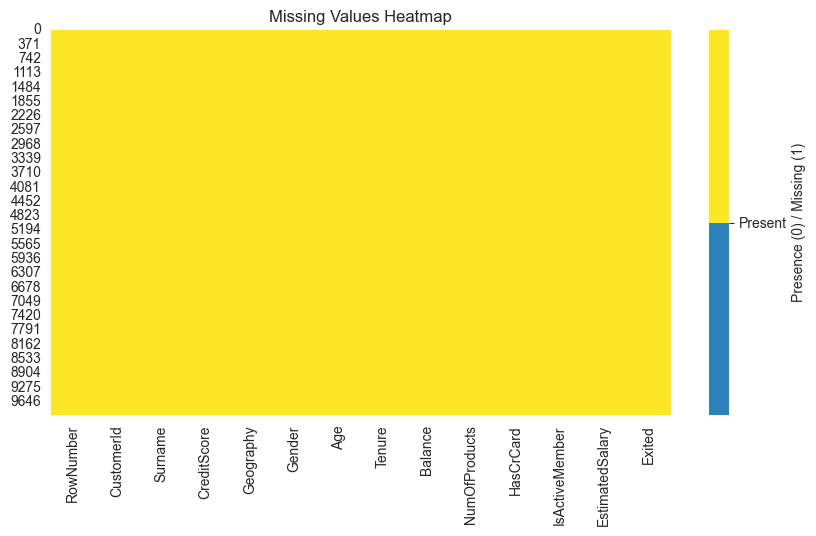

DUPLICATE DATA
Jumlah Duplicate Data : 0
TIPE DATA


RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [8]:
quality = DataQualityCheck(df)

quality.check_missing_values()
quality.check_duplicates()
quality.check_data_types()

## Definisi kelas DescriptiveStatistics

Apa yang dilakukan: 
- Membuat kelas untuk statistik deskriptif

Metode:
- menampilkan ringkasan statistik numerik
- menghitung skewness untuk fitur numerik

Kegunaan:
- Memahami distribusi nilai numerik
- Mengetahui apakah kolom memiliki kemiringan distribusi yang tinggi

In [ ]:
class DescriptiveStatistics:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def descriptive_statistics(self):
        
        print("=" * 50)
        print("STATISTIK DESKRIPTIF")
        print("=" * 50)
        
        display(self.df.describe())
        
    def skewness_check(self):
        
        print("=" * 50)
        print("SKEWNESS")
        print("=" * 50)
        
        numeric_cols = self.df.select_dtypes(
            include=['int64', 'float64']
        )
        
        display(numeric_cols.skew())

## Menjalankan statistik deskriptif

Apa yang dilakukan:
- Membuat objek stats dari DescriptiveStatistics
- Menjalankan deskripsi statistik dan skewness

Kegunaan:
- Menilai data numerik untuk outlier, rentang, rata-rata, dan distribusi
- Menyediakan informasi dasar untuk pemilihan model dan normalisasi

In [ ]:
stats = DescriptiveStatistics(df)

stats.descriptive_statistics()
stats.skewness_check()

STATISTIK DESKRIPTIF


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


SKEWNESS


RowNumber          0.000000
CustomerId         0.001149
CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
Exited             1.471611
dtype: float64